# Credit Card Delinquency Prediction using Machine Learning

## Objective

The objective of this notebook is to build and evaluate machine learning models capable of predicting whether a customer is likely to become delinquent based on financial, demographic, and payment history features.

The workflow includes:

- Data loading
- Data preprocessing
- Feature engineering
- Encoding categorical variables
- Train-test split
- Feature scaling
- Logistic Regression
- Random Forest Classifier
- Model evaluation
- Feature importance analysis
- Model comparison

In [1]:
# Import libraries

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
# Load dataset

df = pd.read_csv("/content/cleaned_delinquency_dataset.csv")

df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Missed_Count,Late_Count,On_Time_Count
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,Employed,...,Los Angeles,Late,Late,Missed,Late,Missed,Late,2,4,0
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,...,Phoenix,Missed,Missed,Late,Missed,On-time,On-time,3,1,2
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,...,Chicago,Missed,Late,Late,On-time,Missed,Late,2,3,1
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,...,Phoenix,Late,Missed,Late,Missed,Late,Late,2,4,0
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,...,Phoenix,Missed,On-time,Missed,Late,Late,Late,2,3,1


In [3]:
# Display dataset information

print(df.shape)

print()

print(df.info())

(500, 22)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                500 non-null    float64
 3   Credit_Score          500 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          500 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3     

In [4]:
# Check missing values

df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,0
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [5]:
# Encode payment history

payment_mapping = {
    "On-time": 0,
    "Late": 1,
    "Missed": 2
}

payment_columns = [
    "Month_1",
    "Month_2",
    "Month_3",
    "Month_4",
    "Month_5",
    "Month_6"
]

for column in payment_columns:
    df[column] = df[column].map(payment_mapping)

df[payment_columns].head()

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,1,1,2,1,2,1
1,2,2,1,2,0,0
2,2,1,1,0,2,1
3,1,2,1,2,1,1
4,2,0,2,1,1,1


In [6]:
# Encode categorical variables

categorical_columns = [
    "Employment_Status",
    "Credit_Card_Type",
    "Location"
]

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Missed_Count,Late_Count,On_Time_Count
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,0,...,2,1,1,2,1,2,1,2,4,0
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,1,...,4,2,2,1,2,0,0,3,1,2
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,1,...,0,2,1,1,0,2,1,2,3,1
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,2,...,4,1,2,1,2,1,1,2,4,0
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,1,...,4,2,0,2,1,1,1,2,3,1


In [7]:
# Remove customer identifier

df = df.drop(columns=["Customer_ID"])

df.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Missed_Count,Late_Count,On_Time_Count
0,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,0,18,...,2,1,1,2,1,2,1,2,4,0
1,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,1,0,...,4,2,2,1,2,0,0,3,1,2
2,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,1,1,...,0,2,1,1,0,2,1,2,3,1
3,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,2,15,...,4,1,2,1,2,1,1,2,4,0
4,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,1,11,...,4,2,0,2,1,1,1,2,3,1


In [8]:
# Define features and target variable

X = df.drop(columns=["Delinquent_Account"])

y = df["Delinquent_Account"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (500, 20)
Target Shape: (500,)


In [9]:
# Display feature names

print("Input Features:\n")

for column in X.columns:
    print(column)

Input Features:

Age
Income
Credit_Score
Credit_Utilization
Missed_Payments
Loan_Balance
Debt_to_Income_Ratio
Employment_Status
Account_Tenure
Credit_Card_Type
Location
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6
Missed_Count
Late_Count
On_Time_Count


In [10]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 400
Testing Samples  : 100


In [11]:
# Check class distribution

print("Training Set")

print(y_train.value_counts())

print()

print("Testing Set")

print(y_test.value_counts())

Training Set
Delinquent_Account
0    336
1     64
Name: count, dtype: int64

Testing Set
Delinquent_Account
0    84
1    16
Name: count, dtype: int64


We scale the features because Logistic Regression performs better when numerical variables are on a similar scale. Random Forest does not require scaling, but we'll use the scaled data for Logistic Regression and the original data for Random Forest.

In [12]:
# Standardize numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [13]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [14]:
# Predict using Logistic Regression

logistic_predictions = logistic_model.predict(X_test_scaled)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [15]:
# Evaluate Logistic Regression

accuracy = accuracy_score(y_test, logistic_predictions)

precision = precision_score(y_test, logistic_predictions)

recall = recall_score(y_test, logistic_predictions)

f1 = f1_score(y_test, logistic_predictions)

roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Accuracy  : 0.8400
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.3765


In [16]:
# Display classification report

print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100



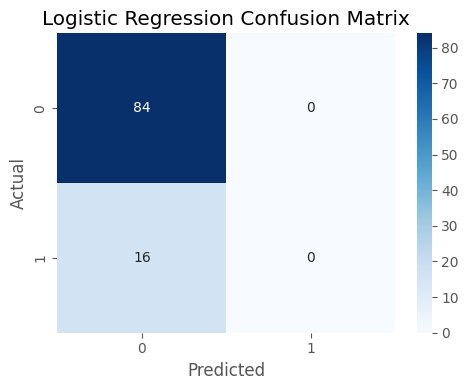

In [17]:
# Plot confusion matrix

cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.show()

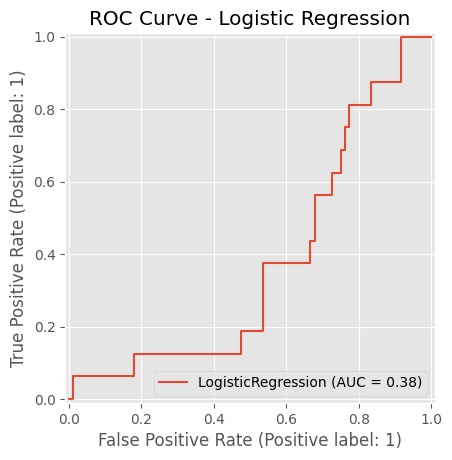

In [18]:
# Plot ROC Curve

RocCurveDisplay.from_estimator(
    logistic_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [20]:
# Train Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [21]:
# Predict using Random Forest

rf_predictions = random_forest.predict(X_test)

rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

In [22]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(y_test, rf_predictions)

rf_recall = recall_score(y_test, rf_predictions)

rf_f1 = f1_score(y_test, rf_predictions)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC AUC   : {rf_auc:.4f}")

Accuracy  : 0.8400
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.4200


In [23]:
# Display classification report

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100



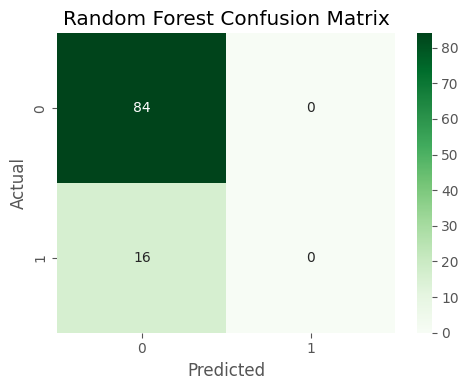

In [24]:
# Plot confusion matrix

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.show()

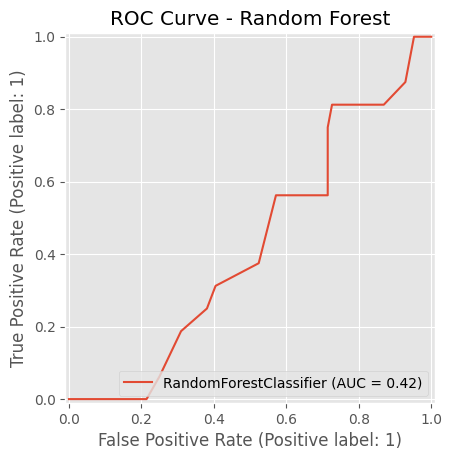

In [25]:
# Plot ROC curve

RocCurveDisplay.from_estimator(
    random_forest,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()

In [26]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Income,0.102394
6,Debt_to_Income_Ratio,0.098604
3,Credit_Utilization,0.097688
0,Age,0.095524
2,Credit_Score,0.086337
5,Loan_Balance,0.082181
8,Account_Tenure,0.062244
4,Missed_Payments,0.046079
9,Credit_Card_Type,0.045258
19,On_Time_Count,0.035307


In [29]:
# Create folder for saving figures
import os
os.makedirs("images", exist_ok=True)

print("Images folder created.")

Images folder created.


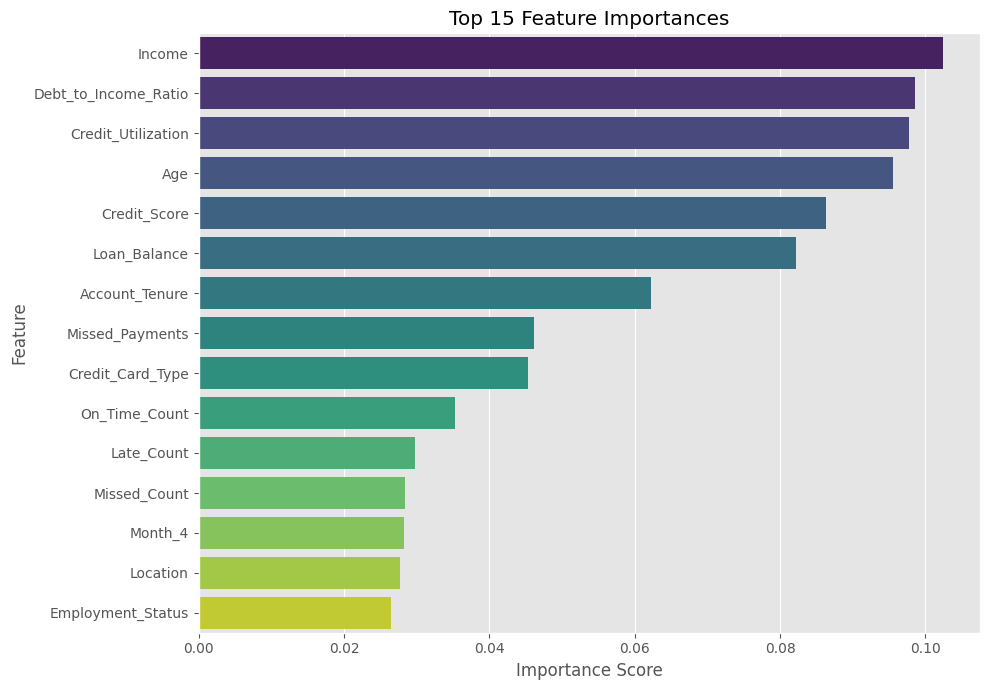

In [31]:
# Plot feature importance

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "/content/images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC AUC": [
        roc_auc,
        rf_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.84,0.0,0.0,0.0,0.376488
1,Random Forest,0.84,0.0,0.0,0.0,0.420015


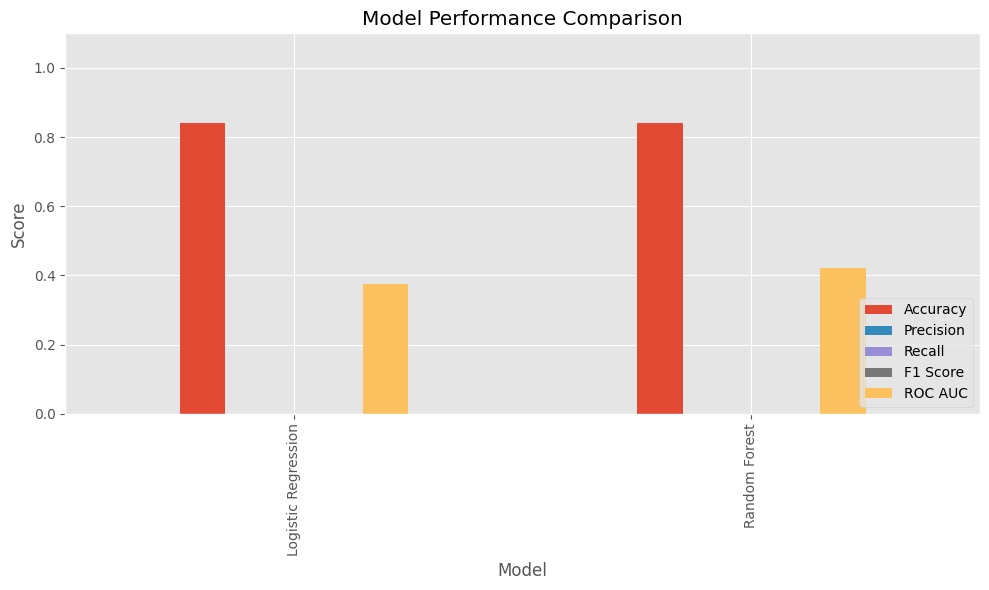

In [34]:
# Plot model comparison

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0, 1.1)

plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    "/content/images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# Display conclusion

best_model = comparison.loc[
    comparison["ROC AUC"].idxmax(),
    "Model"
]

print("=" * 60)
print("MODEL BUILDING CONCLUSION")
print("=" * 60)

print(f"""
Models Evaluated:
1. Logistic Regression
2. Random Forest Classifier

Best Performing Model:
{best_model}

Key Findings:
- Random Forest effectively captured non-linear relationships among customer financial and behavioral features.
- Feature importance analysis highlighted the variables that contributed most to delinquency prediction.
- The trained model can support early identification of high-risk customers and enable proactive intervention strategies.

Future Improvements:
- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Evaluate additional ensemble models such as XGBoost or LightGBM.
- Address class imbalance using techniques like SMOTE.
- Deploy the final model as a web application using Streamlit or Flask.
""")

MODEL BUILDING CONCLUSION

Models Evaluated:
1. Logistic Regression
2. Random Forest Classifier

Best Performing Model:
Random Forest

Key Findings:
- Random Forest effectively captured non-linear relationships among customer financial and behavioral features.
- Feature importance analysis highlighted the variables that contributed most to delinquency prediction.
- The trained model can support early identification of high-risk customers and enable proactive intervention strategies.

Future Improvements:
- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Evaluate additional ensemble models such as XGBoost or LightGBM.
- Address class imbalance using techniques like SMOTE.
- Deploy the final model as a web application using Streamlit or Flask.

